## Calculate Foote Novelty

This script calculates foote novelty transitions inspired by "Professional Jazz Musicians Explore and Exploit a Space of Sounds" (Williams et al., 2024) to explore changes in topic within conversation transcripts. 

**Author:** Helen Schmidt  
**Python version:** 3.11.13

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# define data input location
input_dir = "/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/data/output/full-sample"
# define data output location
output_dir = input_dir

In [57]:
# define function to calculate turn angle
# calculate the cosine similarity of the turn angles, rather than adjacent turns
def compute_turn_angles_adjacent_windows(df):
    results = []

    # group by transcript
    for transcript_id, group in df.groupby('transcript_id'):
        if len(group) < 2:
            continue  # need at least 2 windows to compute a turn
        
        # stack embeddings
        A = np.vstack([emb.squeeze() for emb in group['A_embeddings'].values[:-1]])
        B = np.vstack([emb.squeeze() for emb in group['B_embeddings'].values[:-1]])
        C = np.vstack([emb.squeeze() for emb in group['B_embeddings'].values[1:]])
        
        # vectors from B
        BA = A - B
        BC = C - B
        
        # cosine turn angle
        cos_theta = np.array([
            cosine_similarity(BA[i].reshape(1,-1), BC[i].reshape(1,-1))[0,0]
            for i in range(len(BA))
        ])
        
        # aligned raw turn/time
        a_times = group['A_start_turn'].values[:-1] #A_start_time for time, A_start_turn for turn

        # save results
        res_df = pd.DataFrame({
            'transcript_id': transcript_id,
            'turn_index': np.arange(len(cos_theta)),
            'A_start_turn': a_times, #A_start_time for time, A_start_turn for turn
            'cosine_turn': cos_theta
        })
        
        results.append(res_df)
    
    return pd.concat(results, ignore_index=True)

In [58]:
test = pd.read_pickle(input_dir + '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl')
test.head()

,transcript_id,speaker_mode,mode,window_size,gap_size,A_speaker,B_speaker,A_start_turn,A_end_turn,B_start_turn,B_end_turn,A_utterances,B_utterances,A_embeddings,B_embeddings,cosine_similarity,euclidean_distance
0,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,1,4,1,4,hey I'm gone. yeah I've done a few of these be...,"good, how are you? Yeah. Yeah, so this will be...","[-0.05925276, -0.038165268, 0.042457737, 0.037...","[-0.005335846, -0.054031678, 0.025666948, 0.03...",0.472280,0.641885
1,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,1,4,5,8,"good, how are you? Yeah. Yeah, so this will be...",not too bad. Feel a little crappy today but hu...,"[-0.005335846, -0.054031678, 0.025666948, 0.03...","[-0.06539267, -0.016892936, 0.035326734, 0.000...",0.383021,0.718863
2,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,5,8,5,8,not too bad. Feel a little crappy today but hu...,"I don't know. no, are you getting sick? Oh tha...","[-0.06539267, -0.016892936, 0.035326734, 0.000...","[0.012232751, -0.02369256, 0.021855786, 0.0089...",0.451708,0.668791
3,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5fa072f4f4aa580b63834357,5a73899f9cdd1800017786f0,5,8,9,12,"I don't know. no, are you getting sick? Oh tha...",22 girls if I'm enjoy it while you can they've...,"[0.012232751, -0.02369256, 0.021855786, 0.0089...","[0.010743233, -0.03177115, -0.0020472077, 0.03...",0.317040,0.707071
4,0020a0c5-1658-4747-99c1-2839e736b481,by_speaker,turn,4,0,5a73899f9cdd1800017786f0,5fa072f4f4aa580b63834357,9,12,9,12,22 girls if I'm enjoy it while you can they've...,that's awesome. So I have no kids myself not a...,"[0.010743233, -0.03177115, -0.0020472077, 0.03...","[-0.017096415, -0.017585017, -0.0006486433, 0....",0.542900,0.587993


## Load Data

We have four data sets - the primary splits long utterances at the sentence level and looks at the speaker level.

The other data sets split long utterances at the word level and speaker level, at the word level and regardless of speaker, and at the word level and at the speaker level.

In [59]:
# create a list of the data files
files = ['/full_sample_tile_4_turn_split_sentences.pkl', '/full_sample_tile_4_turn_split_utterances.pkl', '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl', '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl']

# create containers for all results
foote_results = {}
turn_angle_results = {}

# loop through files and calculate foote novelty
for f in files:

    # read in the data file
    df = pd.read_pickle(input_dir + f)

    # get turn angle cosine similarity
    df_turn_angle = compute_turn_angles_adjacent_windows(df)

    # calculate foote novelty
    all_results = []
    type = 'A_start_turn'

    for transcript_id, group in df.groupby('transcript_id'):
        # sort by conversation within each transcript
        group = group.sort_values(type).reset_index(drop=True)
        
        # construct a full embedding trajectory (starting with first A_embeddings and ending with last B_embeddings)
        embeddings_list = [emb.squeeze() for emb in group['A_embeddings'].values]
        embeddings_list.append(group['B_embeddings'].values[-1].squeeze())
        embeddings = np.vstack(embeddings_list)

        n = embeddings.shape[0]
        if n < 4: continue

        # build time list (one per A, then repeat the last A time for final B)
        time_list = list(group[type].values)
        time_list.append(time_list[-1]) # align with B_embeddings row

        # determine if this is speaker-based or overall
        speaker_based = 'by_speaker' in f

        # build speaker list if speaker-based
        if speaker_based and 'speaker' in group.columns:
            speaker_list = list(group['speaker'].values)
            speaker_list.append(speaker_list[-1])
        else:
            speaker_list = [None] * n  # placeholder if no speaker

        # compute self-similarity matrix (how similar is each embedding to all other embeddings in the convo?)
        # https://ccrma.stanford.edu/workshops/mir2009/references/Foote_00.pdf 
        S = cosine_similarity(embeddings)

        # build the checkerboard kernel
        kernel_size = 10 # bigger values = detect larger shifts
        k = kernel_size // 2
        kernel = np.block([
            [np.ones((k, k)), -np.ones((k, k))],
            [-np.ones((k, k)), np.ones((k, k))]
        ])
        kernel = kernel / np.sqrt((kernel_size ** 2) / 2)

        # compute foote novelty
        novelty = np.zeros(n)
        for i in range(k, n - k):
            sub = S[i - k:i + k, i - k:i + k]
            novelty[i] = np.sum(sub * kernel)

        # normalize the novelty scores from 0 to 1
        novelty = (novelty - novelty.min()) / (novelty.max() - novelty.min() + 1e-8)

        # save results for this transcript
        temp = pd.DataFrame({
            'transcript_id': transcript_id,
            'time_index': np.arange(n),   # each embedding position
            'A_start_turn': time_list,    # save raw info
            'foote_novelty': novelty,
            'speaker': speaker_list
        })
        all_results.append(temp)

    # combine all transcripts
    foote_df = pd.concat(all_results, ignore_index=True)

    # mark predicted shifts when foote novelty is 1.5 SD away from overall transcript mean foote novelty
    foote_df['predicted_shift'] = 0

    for tid, group in foote_df.groupby('transcript_id'):
        mean_nov = group['foote_novelty'].mean()
        std_nov  = group['foote_novelty'].std()
        threshold = mean_nov + 0.5 * std_nov #1.5x, 0.75x
    
        # mark points above threshold
        idx = group.index[group['foote_novelty'] > threshold]
        foote_df.loc[idx, 'predicted_shift'] = 1

        # save threshold
        foote_df.loc[group.index, 'threshold'] = threshold

    # ---- save ----- #
    
    # get data name from filename
    data_name = f.replace(".pkl", "").replace("/", "")

    # store in dictionary created at the beginning
    foote_results[data_name] = foote_df

    # store turn angle results too
    turn_angle_results[data_name] = df_turn_angle

    # save
    foote_df.to_csv(f"{output_dir}/foote_{data_name}.csv", index=False)
    foote_df.to_pickle(f"{output_dir}/foote_{data_name}.pkl")


## Data Previews + Plots

In [50]:
# plot example conversation's peaks of cosine similarities
transcript_id = '0020a0c5-1658-4747-99c1-2839e736b481'

0.6672425497830365


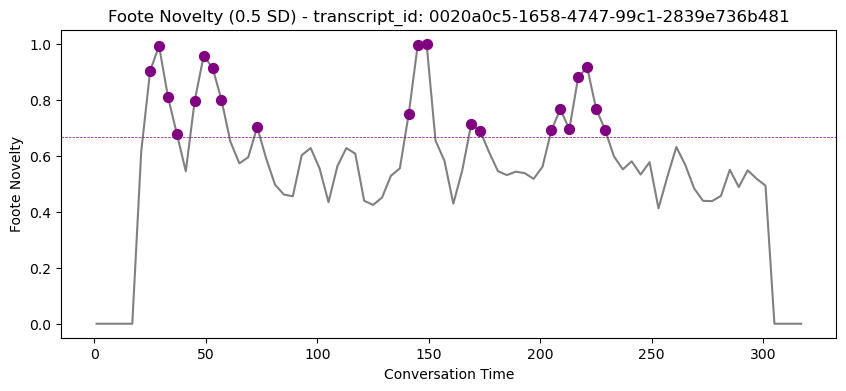

                           transcript_id  time_index  A_start_turn  \
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
9   0020a0c5-1658-4747-99c1-2839e736b481           9            37   
11  0020a0c5-1658-4747-99c1-2839e736b481          11            45   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
18  0020a0c5-1658-4747-99c1-2839e736b481          18            73   
35  0020a0c5-1658-4747-99c1-2839e736b481          35           141   
36  0020a0c5-1658-4747-99c1-2839e736b481          36           145   
37  0020a0c5-1658-4747-99c1-2839e736b481          37           149   
42  0020a0c5-1658-4747-99c1-2839e736b481          42           169   
43  0020a0c5-1658-47

In [51]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_sentences"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6397162401377241


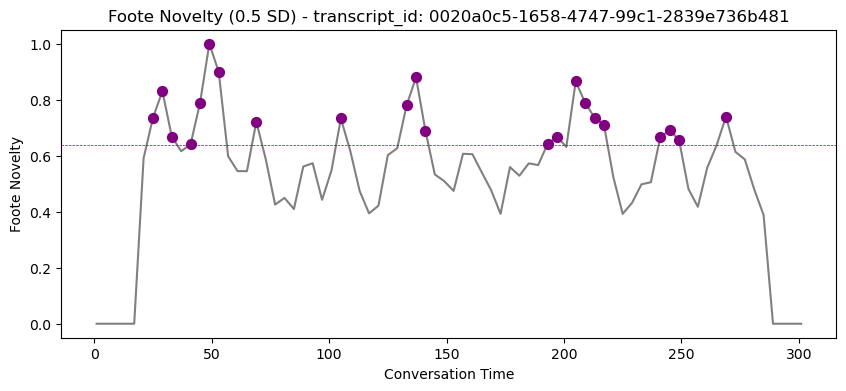

                           transcript_id  time_index  A_start_turn  \
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
10  0020a0c5-1658-4747-99c1-2839e736b481          10            41   
11  0020a0c5-1658-4747-99c1-2839e736b481          11            45   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
26  0020a0c5-1658-4747-99c1-2839e736b481          26           105   
33  0020a0c5-1658-4747-99c1-2839e736b481          33           133   
34  0020a0c5-1658-4747-99c1-2839e736b481          34           137   
35  0020a0c5-1658-4747-99c1-2839e736b481          35           141   
48  0020a0c5-1658-4747-99c1-2839e736b481          48           193   
49  0020a0c5-1658-47

In [52]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_utterances"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6711303626954012


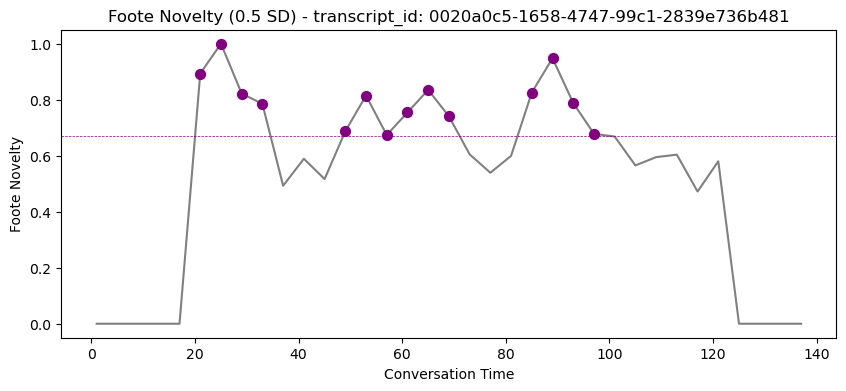

                           transcript_id  time_index  A_start_turn  \
5   0020a0c5-1658-4747-99c1-2839e736b481           5            21   
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
15  0020a0c5-1658-4747-99c1-2839e736b481          15            61   
16  0020a0c5-1658-4747-99c1-2839e736b481          16            65   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
21  0020a0c5-1658-4747-99c1-2839e736b481          21            85   
22  0020a0c5-1658-4747-99c1-2839e736b481          22            89   
23  0020a0c5-1658-4747-99c1-2839e736b481          23            93   
24  0020a0c5-1658-47

In [53]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_sentences_by_speaker"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

0.6761744435172425


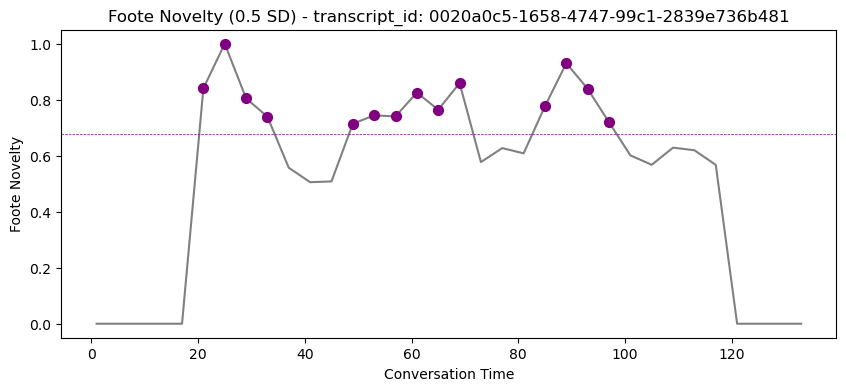

                           transcript_id  time_index  A_start_turn  \
5   0020a0c5-1658-4747-99c1-2839e736b481           5            21   
6   0020a0c5-1658-4747-99c1-2839e736b481           6            25   
7   0020a0c5-1658-4747-99c1-2839e736b481           7            29   
8   0020a0c5-1658-4747-99c1-2839e736b481           8            33   
12  0020a0c5-1658-4747-99c1-2839e736b481          12            49   
13  0020a0c5-1658-4747-99c1-2839e736b481          13            53   
14  0020a0c5-1658-4747-99c1-2839e736b481          14            57   
15  0020a0c5-1658-4747-99c1-2839e736b481          15            61   
16  0020a0c5-1658-4747-99c1-2839e736b481          16            65   
17  0020a0c5-1658-4747-99c1-2839e736b481          17            69   
21  0020a0c5-1658-4747-99c1-2839e736b481          21            85   
22  0020a0c5-1658-4747-99c1-2839e736b481          22            89   
23  0020a0c5-1658-4747-99c1-2839e736b481          23            93   
24  0020a0c5-1658-47

In [38]:
# subset to one type of data
this_data = foote_results["full_sample_tile_4_turn_split_utterances_by_speaker"]
subset = this_data[this_data['transcript_id'] == transcript_id].reset_index(drop=True)
predicted_shift_points = subset[subset['predicted_shift'] == 1]

threshold_val = subset['threshold'].iloc[0]   # get threshold value for this transcript
print(threshold_val) # print threshold

plt.figure(figsize=(10, 4))
sns.lineplot(data=subset, x='A_start_turn', y='foote_novelty', color = 'grey')
plt.scatter(predicted_shift_points['A_start_turn'], predicted_shift_points['foote_novelty'], color = 'purple', s = 50, zorder = 3)
plt.axhline(y=threshold_val, linestyle='--', linewidth=0.5, color='purple')
plt.title(f'Foote Novelty (0.5 SD) - transcript_id: {transcript_id}')
plt.xlabel('Conversation Time')
plt.ylabel('Foote Novelty')
plt.show()

## print predicted shifts
print(subset[subset['predicted_shift'] == 1])

## Distributions

### Overall, split on utterances

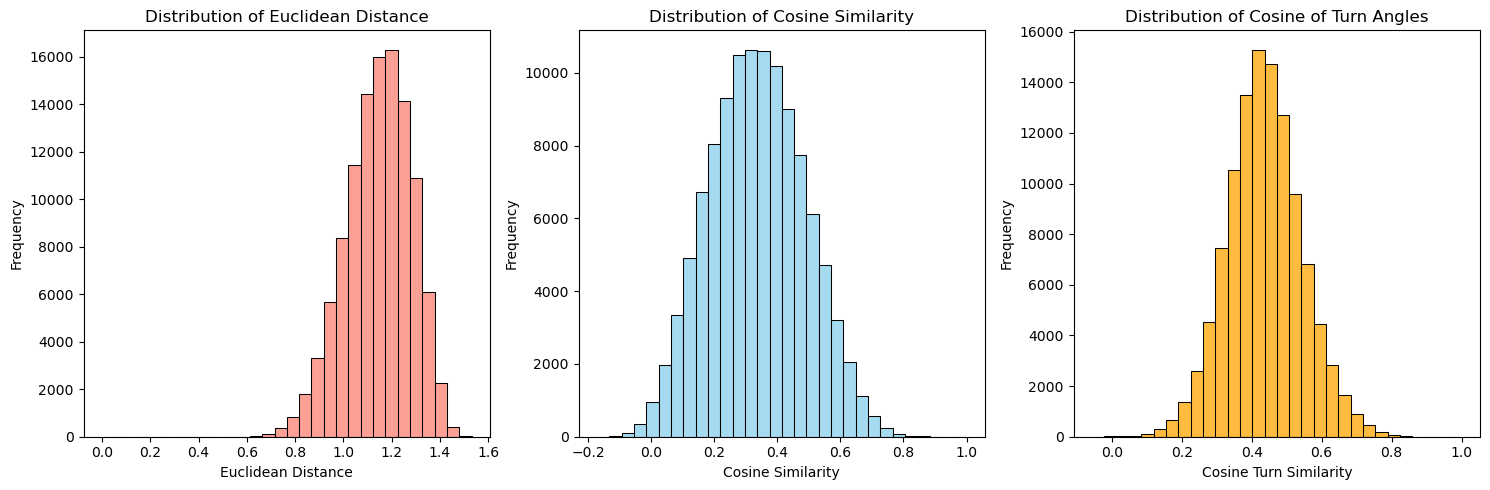

In [40]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances.pkl')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_utterances']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Overall, split on sentences

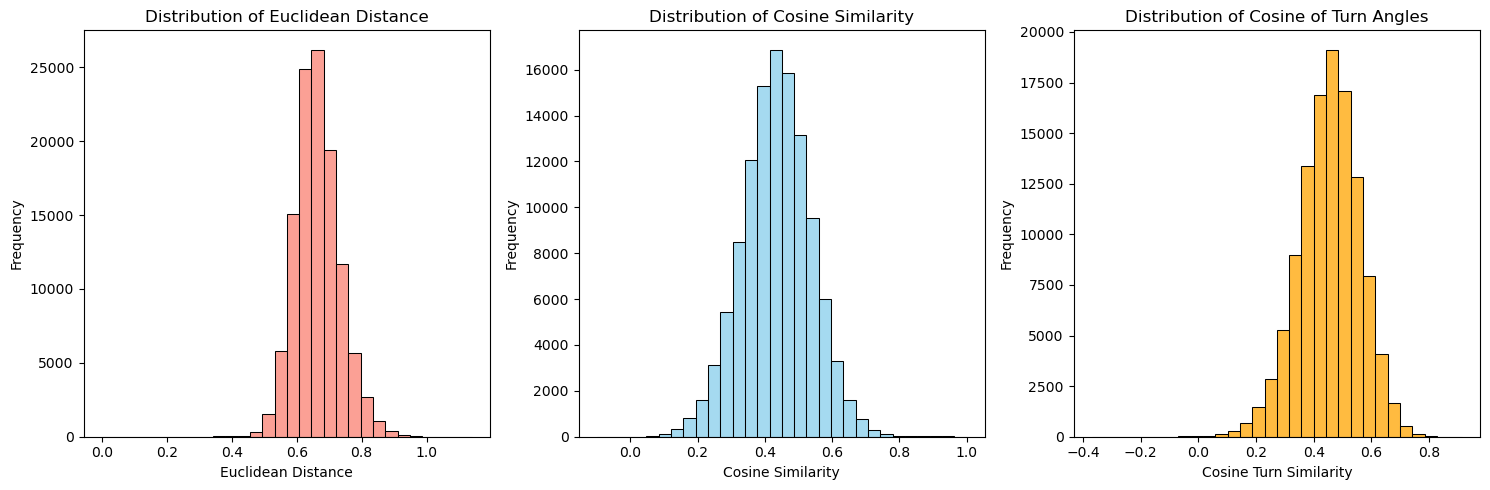

In [41]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_sentences.pkl')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_sentences']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Speaker, split by utterances

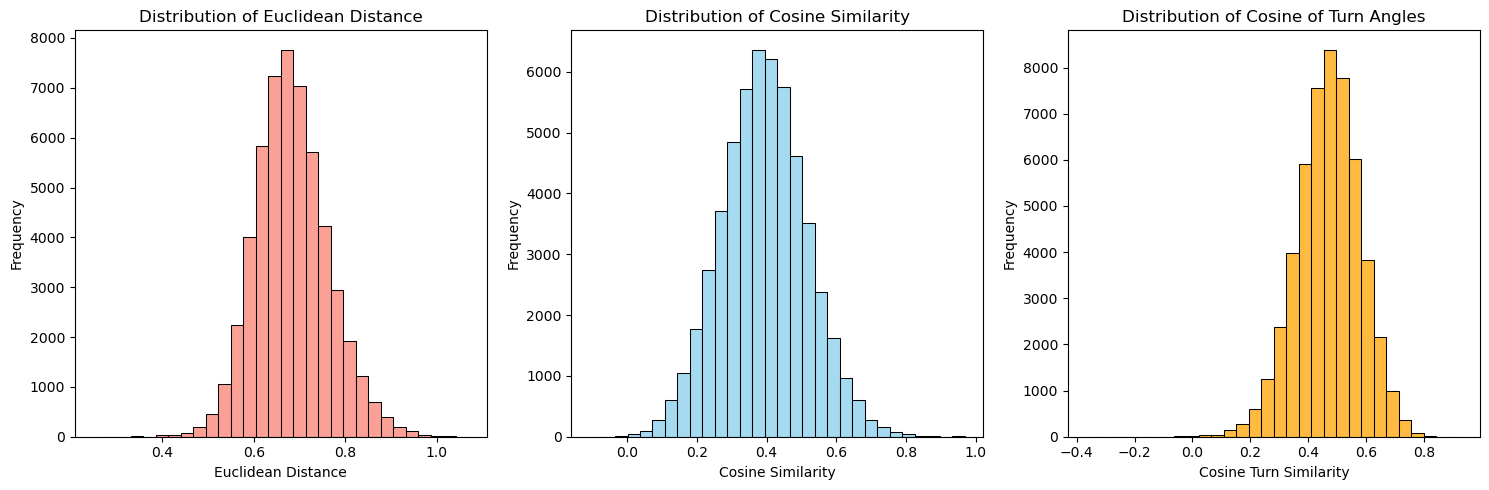

In [42]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances_by_speaker.pkl')
this_data = this_data.drop_duplicates(subset=['transcript_id', 'A_start_turn'], keep='first')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_utterances_by_speaker']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

### Speaker, split by sentences

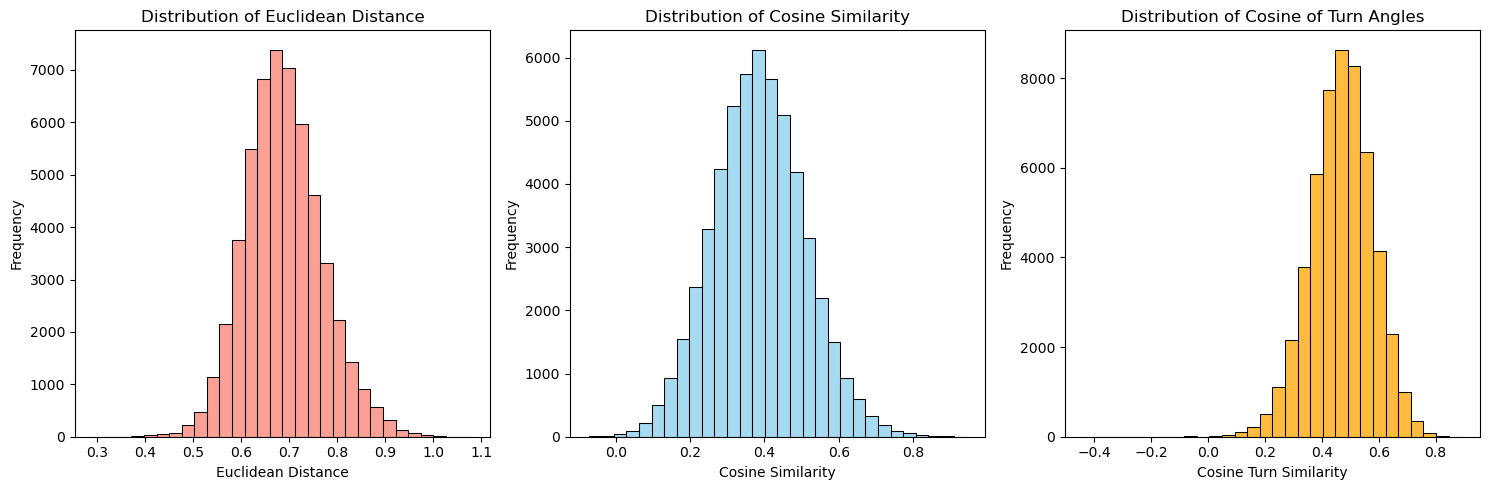

In [43]:
this_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_sentences_by_speaker.pkl')
this_data = this_data.drop_duplicates(subset=['transcript_id', 'A_start_turn'], keep='first')
this_turn_data = turn_angle_results['full_sample_tile_4_turn_split_sentences_by_speaker']

# plot distributions of cosine similarity and euclidean distances and cosine of turn angles
# create figure / axes
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# plot A - step length (euclidean distance)
sns.histplot(this_data['euclidean_distance'], bins=30, kde=False, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Euclidean Distance')
axes[0].set_xlabel('Euclidean Distance')
axes[0].set_ylabel('Frequency')

# plot B - cosine similarity
sns.histplot(this_data['cosine_similarity'], bins=30, kde=False, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Cosine Similarity')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# plot C - turn angles
sns.histplot(this_turn_data['cosine_turn'], bins=30, kde=False, ax=axes[2], color="orange")
axes[2].set_title('Distribution of Cosine of Turn Angles')
axes[2].set_xlabel('Cosine Turn Similarity')
axes[2].set_ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

## Conversation Heatmaps

In [8]:
# define data to create heatmaps (main = overall split long utterances maintaining sentences)
heatmap_data = df = pd.read_pickle(output_dir + '/full_sample_tile_4_turn_split_utterances.pkl')
# create a test subset before plotting
test_heatmap = heatmap_data[heatmap_data["transcript_id"] == heatmap_data["transcript_id"].iloc[0]].copy()
# define folder output
heatmap_output = '/Users/helenschmidt/Library/CloudStorage/GoogleDrive-helenschmidt129@gmail.com/My Drive/SANLab/Experiments/Conversation-Structure/Candor/analysis-full/output'

# create a folder in the full sample data output to save heatmaps
euclidean_dir = os.path.join(heatmap_output, "euclidean-distance-heatmaps")
os.makedirs(euclidean_dir, exist_ok=True)

cosine_dir = os.path.join(heatmap_output, "cosine-similarity-heatmaps")
os.makedirs(cosine_dir, exist_ok=True)

# preview test subset
test_heatmap.head()

,transcript_id,mode,window_size,gap_size,A_start_turn,A_end_turn,B_start_turn,B_end_turn,A_raw_start,A_raw_end,B_raw_start,B_raw_end,A_utterances,B_utterances,A_embeddings,B_embeddings,cosine_similarity,euclidean_distance
0,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,1,4,5,8,200.74,214.56,214.03,230.46,"hey I'm gone. good, how are you? Yeah. Yeah, s...",too bad. Is this your first time doing? this i...,"[[0.04145282, -0.00791257, 0.104940765, 0.1183...","[[0.03092037, -0.10058955, 0.0143238, -0.01912...",0.440620,1.057715
1,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,5,8,9,12,214.03,230.46,231.64,244.66,too bad. Is this your first time doing? this i...,not too bad. Feel a little crappy today but hu...,"[[0.03092037, -0.10058955, 0.0143238, -0.01912...","[[0.0076957764, -0.0027738144, 0.038302507, -0...",0.276866,1.202609
2,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,9,12,13,16,231.64,244.66,244.07,276.46,not too bad. Feel a little crappy today but hu...,the kid hasn't been feeling good and I think s...,"[[0.0076957764, -0.0027738144, 0.038302507, -0...","[[-0.042489365, 0.021653492, 0.09216961, -0.04...",0.522794,0.976940
3,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,13,16,17,20,244.07,276.46,277.02,317.65,the kid hasn't been feeling good and I think s...,22 girls if I'm that's awesome. So I have no k...,"[[-0.042489365, 0.021653492, 0.09216961, -0.04...","[[0.037868235, -0.0063665304, 0.023072034, 0.0...",0.177692,1.282426
4,0020a0c5-1658-4747-99c1-2839e736b481,turn,4,0,17,20,21,24,277.02,317.65,317.59,333.26,22 girls if I'm that's awesome. So I have no k...,they've both been pretty good as far as stayin...,"[[0.037868235, -0.0063665304, 0.023072034, 0.0...","[[-0.019834107, -0.07536617, -0.018573657, 0.0...",0.332540,1.155388


### Euclidean Distance

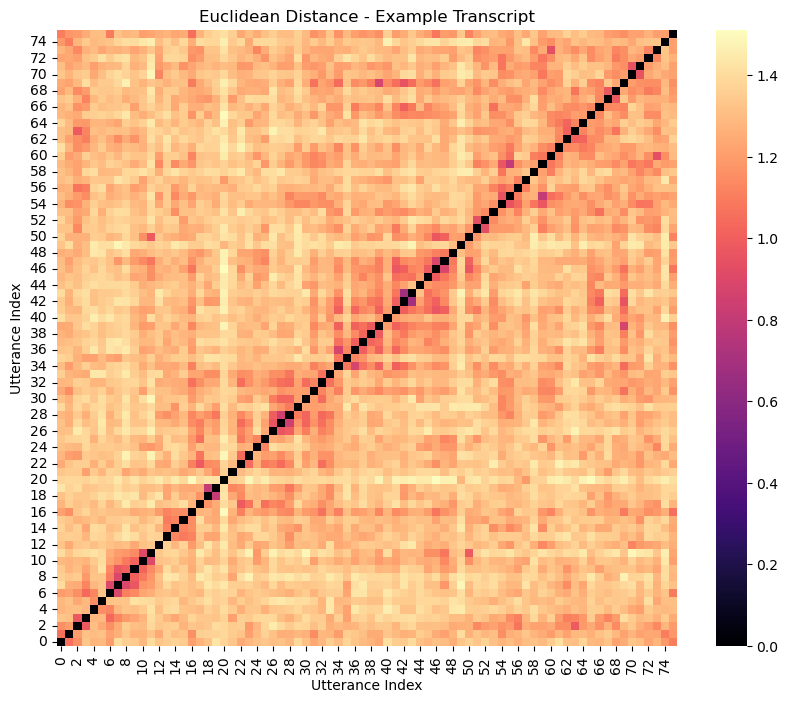

In [9]:
# test euclidean heatmap
embeddings_matrix = np.vstack(test_heatmap['A_embeddings'].values) # get embeddings
distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric = "euclidean")

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=False, cmap='magma')
plt.title(f'Euclidean Distance - Example Transcript')
plt.gca().invert_yaxis()
plt.xlabel('Utterance Index')
plt.ylabel('Utterance Index')
plt.show()

In [7]:
# --- EUCLIDEAN DISTANCE PLOTS --- #
# loop through each unique transcript_id
for transcript_id in heatmap_data['transcript_id'].unique():
    subset = heatmap_data[heatmap_data['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # stack embeddings into a matrix
        embedding_matrix = np.vstack(subset['A_embeddings'].values)
        # compute pairwise euclidean distance
        distance_matrix = cdist(embedding_matrix, embedding_matrix, metric = "euclidean")
        # plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(distance_matrix, annot=False, cmap='magma')
        plt.title(f'Euclidean Distance - transcript_id: {transcript_id}')
        plt.gca().invert_yaxis()
        plt.xlabel('Utterance Index')
        plt.ylabel('Utterance Index')
        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(euclidean_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")

### Cosine Similarity

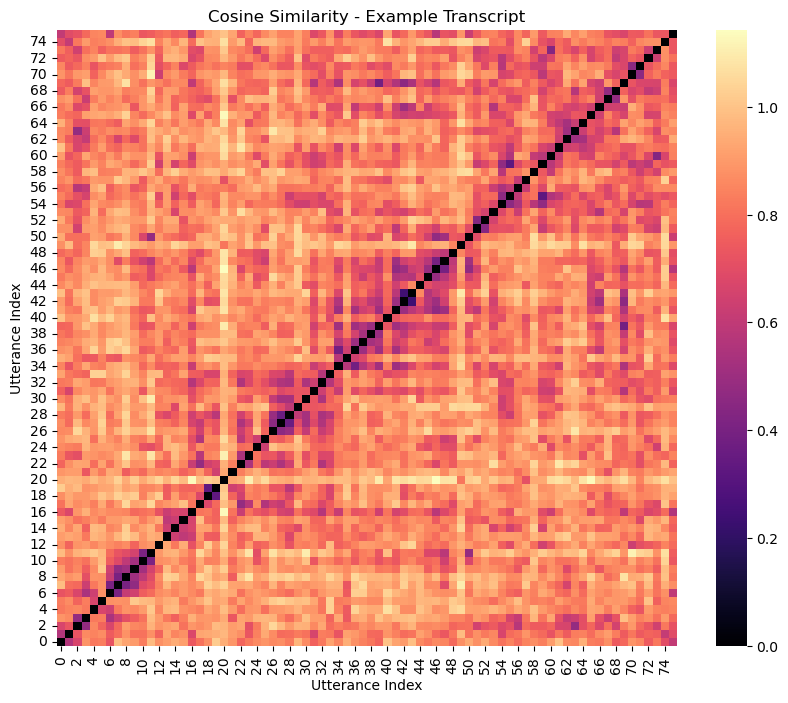

In [10]:
# test cosine heatmap
embeddings_matrix = np.vstack(test_heatmap['A_embeddings'].values) # get embeddings
distance_matrix = cdist(embeddings_matrix, embeddings_matrix, metric = "cosine")

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, annot=False, cmap='magma')
plt.title(f'Cosine Similarity - Example Transcript')
plt.gca().invert_yaxis()
plt.xlabel('Utterance Index')
plt.ylabel('Utterance Index')
plt.show()

In [11]:
# --- COSINE SIMILARITY PLOTS --- #
# loop through each unique transcript_id
for transcript_id in heatmap_data['transcript_id'].unique():
    subset = heatmap_data[heatmap_data['transcript_id'] == transcript_id].reset_index(drop=True)
    # add in skip if not enough data exists to compute distances
    if subset.empty or subset.shape[0] < 2:
        continue
    try:
        # stack embeddings into a matrix
        embedding_matrix = np.vstack(subset['A_embeddings'].values)
        # compute pairwise euclidean distance
        distance_matrix = cdist(embedding_matrix, embedding_matrix, metric = "cosine")
        # plot heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(distance_matrix, annot=False, cmap='magma')
        plt.title(f'Euclidean Distance - transcript_id: {transcript_id}')
        plt.gca().invert_yaxis()
        plt.xlabel('Utterance Index')
        plt.ylabel('Utterance Index')
        # save each plot
        save_id = transcript_id.replace('/', '_')  # edit ID in case there are problematic characters
        plot_path = os.path.join(cosine_dir, f"{save_id}.png")
        plt.savefig(plot_path, bbox_inches='tight')
        plt.close()

    except Exception as e:
        print(f"Error creating heatmap for {transcript_id}: {e}")

### Cosine of Turn Angle